# Notebook 07 — Uncertainty propagation and global sensitivity (Gate V4, F6, F7)

Gate V4 certifies the machinery; the machinery then produces the project's two
headline results. This notebook runs both parts in that order, because the
order is the point: the tolerances were pre-registered in
`docs/validation_plan.md` before `uq.py` and `sensitivity.py` existed, and the
git history of that file is the evidence.

All physics lives in the `h2star` package.

**Two limits apply to every number below.** The material-parameter covariance
is conditional on a fixed pseudo-saturation pressure, so every interval here is
a LOWER bound on the spread a single published isotherm implies. And this layer
quantifies spread, not bias: Gate V3 measured the system mass denominator as
light by a factor of about 4.2, which is an order of magnitude beyond the widest
band declared in `data/uncertainty.yaml`. An interval computed here surrounds an
optimistic central estimate.

In [1]:
%matplotlib inline

from pathlib import Path

import numpy as np

from h2star import envelope, inverse, isotherm, sensitivity, system, uq
from h2star.viz import plot_sobol_indices

In [2]:
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").is_dir():
    REPO_ROOT = Path("..").resolve()

material = isotherm.Material.from_yaml(REPO_ROOT / "data" / "materials" / "ax21.yaml")
da = isotherm.ModifiedDA(material)
engineering = system.EngineeringParams.from_yaml(REPO_ROOT / "data" / "engineering.yaml")
targets = inverse.load_doe_targets(
    REPO_ROOT / "data" / "targets" / "doe_targets.yaml", "2025")
spec = uq.UncertaintySpec.from_yaml(REPO_ROOT / "data" / "uncertainty.yaml")

print(f"material : {material.name}")
print(f"targets  : {targets.label} - GC >= {targets.gc} kg/kg, VC >= {targets.vc} kg/L")
print(f"UQ layers: material {spec.material.parameters} + scalars {spec.scalar_names}")

material : AX-21
targets  : DOE 2025 - GC >= 0.055 kg/kg, VC >= 0.04 kg/L
UQ layers: material ('n_max', 'alpha', 'v_a') + scalars ('sigma_allow', 'mli_k_eff', 'heat_leak_budget', 'bop_fixed', 'rho_bulk')


## Gate V4.2 — the Sobol machinery against the Ishigami closed form

The Ishigami function has a known variance decomposition, and it is a test
rather than a demonstration because its third input has a first-order index of
exactly zero yet a substantial total-order index. An implementation that
confused the two, or that missed interactions, cannot pass.

The closed form is derived in `sensitivity.ishigami_analytic` rather than quoted
from a secondary source. The pre-registered ladder runs 2^14, 2^16, 2^18, and
the error must fall across it: raising the sample size is part of the procedure,
not a rescue applied after a failure.

In [3]:
analytic = sensitivity.ishigami_analytic()
print(f"analytic variance = {analytic['variance']:.10f}")
print(f"analytic S1 = {np.array2string(analytic['S1'], precision=10)}")
print(f"analytic ST = {np.array2string(analytic['ST'], precision=10)}")
print()

previous = None
for power in (14, 16, 18):
    result = sensitivity.sobol_test_ishigami(n=2**power, seed=0)
    worst = result["worst_relative_error"]
    falling = "" if previous is None else f"  (fell from {100*previous:.4f}%)"
    print(f"N = 2^{power:<2d} ({result['n_evaluations']:>9,d} evals): "
          f"worst relative error {100*worst:8.4f}%{falling}")
    print(f"            |S1 for x3| = {result['S1_x3_absolute_error']:.3e} "
          f"(analytic value is exactly 0)")
    previous = worst
    final = result

print()
print("Gate V4.2 verdict, against the pre-registered bands:")
print(f"  S1 (x1, x2) within 5% : "
      f"{bool((final['S1_relative_error'] <= 0.05).all())}")
print(f"  ST (all three) within 5%: "
      f"{bool((final['ST_relative_error'] <= 0.05).all())}")
print(f"  |S1 for x3| <= 0.05 abs : "
      f"{final['S1_x3_absolute_error'] <= 0.05}")

analytic variance = 13.8445879407
analytic S1 = [0.3139051911 0.4424111448 0.          ]
analytic ST = [0.5575888552 0.4424111448 0.2436836641]



N = 2^14 (   81,920 evals): worst relative error   0.1885%
            |S1 for x3| = 1.104e-04 (analytic value is exactly 0)


N = 2^16 (  327,680 evals): worst relative error   0.0047%  (fell from 0.1885%)
            |S1 for x3| = 1.966e-05 (analytic value is exactly 0)


N = 2^18 (1,310,720 evals): worst relative error   0.0008%  (fell from 0.0047%)
            |S1 for x3| = 2.234e-06 (analytic value is exactly 0)

Gate V4.2 verdict, against the pre-registered bands:
  S1 (x1, x2) within 5% : True
  ST (all three) within 5%: True
  |S1 for x3| <= 0.05 abs : True


## The material layer, and why it is seeded the way it is

Gate V2 found the modified Dubinin-Astakhov parameters non-identifiable from a
single published isotherm, and the unconstrained fit's covariance is invalid
because its optimizer stopped at an active bound. The pre-registration therefore
seeds the Monte Carlo from the fixed-p0 conditional covariance.

The rejection rate against the physical domain is reported rather than assumed:
samples outside it are discarded and redrawn, and the pre-registration requires
the truncation to be named as a limitation if it exceeds 1%.

In [4]:
print("material layer, as declared:")
print(f"  parameters : {spec.material.parameters}")
print(f"  mean       : {np.array2string(spec.material.mean, precision=6)}")
print(f"  1-sigma    : "
      f"{np.array2string(np.sqrt(np.diag(spec.material.covariance)), precision=6)}")
print(f"  held fixed : {spec.material.fixed}")
print()
print("correlation matrix (the reason marginals would not do):")
sigma = np.sqrt(np.diag(spec.material.covariance))
print(np.array2string(spec.material.covariance / np.outer(sigma, sigma),
                      precision=3))
print()
for scalar in spec.engineering:
    print(f"  {scalar.name:18s} {scalar.distribution:11s} {scalar.params}  "
          f"[{scalar.status}]")
print()
print("deliberately excluded, with reasons recorded in the data file:")
for name in spec.excluded:
    print(f"  {name}")

material layer, as declared:
  parameters : ('n_max', 'alpha', 'v_a')
  mean       : [6.782351e+01 3.266151e+03 1.422881e-03]
  1-sigma    : [7.825902e+00 2.048716e+02 3.666702e-04]
  held fixed : {'p0': 1470000000.0, 'beta': 18.9}

correlation matrix (the reason marginals would not do):
[[ 1.    -0.965  0.942]
 [-0.965  1.    -0.842]
 [ 0.942 -0.842  1.   ]]

  sigma_allow        triangular  {'low': 1560600000.0, 'mode': 1836000000.0, 'high': 2111400000.0}  [MODELING ASSUMPTION (range not sourced)]
  mli_k_eff          triangular  {'low': 0.000312, 'mode': 0.00052, 'high': 0.000728}  [MODELING ASSUMPTION (range not sourced)]
  heat_leak_budget   uniform     {'low': 5.0, 'high': 7.0}  [SOURCED (range spans two published values)]
  bop_fixed          triangular  {'low': 8.0, 'mode': 16.0, 'high': 24.0}  [SOURCED (range specified by the project's own assumptions stress test)]
  rho_bulk           uniform     {'low': 270.0, 'high': 300.0}  [MODELING ASSUMPTION (range not sourced)]

delibe

## Gates V4.1 and V4.3 — propagation through the system model

The analytic linear-Gaussian check lives in the test suite, where it runs on
every push (`tests/test_uq.py::test_gate_v4_1_...`). What this notebook runs is
the propagation itself, at the baseline envelope, with the half-sample
convergence criterion that V4.3 pre-registers.

In [5]:
baseline = envelope.OperatingPoint(P_full=100.0e5, T_full=80.0)

propagated = uq.propagate_system(
    spec, material, engineering, baseline,
    n=2000, targets=targets, seed=0)

sample = propagated["material_sample"]
print(f"material draws: {sample.n_drawn:,} attempted, "
      f"{sample.n_rejected} rejected "
      f"({100*sample.discard_fraction:.4f}%)")
print(f"truncation must be reported as a limitation: "
      f"{sample.truncation_material}")
print(f"failed model evaluations: {propagated['n_failed']}")
print()
for key, unit, target in (("GC", "kg/kg", targets.gc), ("VC", "kg/L", targets.vc)):
    s = propagated[f"summary_{key}"]
    c = propagated[f"convergence_{key}"]
    print(f"{key} ({unit}):")
    print(f"  median {s['median']:.5f}   68% [{s['interval_68'][0]:.5f}, "
          f"{s['interval_68'][1]:.5f}]   95% [{s['interval_95'][0]:.5f}, "
          f"{s['interval_95'][1]:.5f}]")
    print(f"  P(meets {target} {unit}) = {s['p_meets_target']:.4f}")
    print(f"  converged: {c['converged']} "
          f"(worst half-sample disagreement {100*c['worst_relative_difference']:.3f}% "
          f"on {c['worst_statistic']}, tolerance 2%)")

material draws: 2,000 attempted, 0 rejected (0.0000%)
truncation must be reported as a limitation: False
failed model evaluations: 0

GC (kg/kg):
  median 0.06583   68% [0.06272, 0.06933]   95% [0.06014, 0.07273]
  P(meets 0.055 kg/kg) = 1.0000
  converged: True (worst half-sample disagreement 0.841% on p5, tolerance 2%)
VC (kg/L):
  median 0.02634   68% [0.02475, 0.02795]   95% [0.02323, 0.02942]
  P(meets 0.04 kg/L) = 0.0000
  converged: True (worst half-sample disagreement 1.105% on p5, tolerance 2%)


## Separating the two layers, which is what claim C5 needs

C5 is specifically that MATERIAL-parameter uncertainty alone blurs the
feasibility boundary. Running the layers separately is how that is established
rather than asserted.

In [6]:
for label, kwargs in (("material only", {"include_engineering": False}),
                      ("engineering only", {"include_material": False}),
                      ("both", {})):
    result = uq.propagate_system(
        spec, material, engineering, baseline, n=2000, targets=targets,
        seed=0, **kwargs)
    s = result["summary_GC"]
    width = s["interval_68"][1] - s["interval_68"][0]
    print(f"{label:18s} GC median {s['median']:.5f}  "
          f"68% width {width:.6f} kg/kg")

material only      GC median 0.06425  68% width 0.003638 kg/kg


engineering only   GC median 0.06696  68% width 0.005942 kg/kg


both               GC median 0.06583  68% width 0.006607 kg/kg


## The two-envelope Sobol study — claim C3

The question is whether the property that controls system performance changes
with operating regime. Cryogenic and ambient are run at the same pressure so
that only the temperature regime differs.

A caution that belongs with every index: Saltelli sampling needs a box, so each
declared distribution is widened to a uniform over its support and the material
correlation is discarded. The indices are therefore of an independent-input
surrogate. They rank relative influence; they are not a decomposition of the
Monte Carlo variance computed above.

In [7]:
cryogenic = envelope.OperatingPoint(P_full=100.0e5, T_full=80.0)
ambient = envelope.OperatingPoint(P_full=100.0e5, T_full=298.0, T_empty=298.0)

studies, labels = [], []
for label, point in (("Cryogenic: 80 K full, 160 K empty", cryogenic),
                     ("Ambient: 298 K isothermal", ambient)):
    study = sensitivity.sobol_indices(
        spec, material, engineering, point, n=512, seed=0)
    studies.append(study)
    labels.append(label)
    print(f"{label}")
    print(f"  {study['n_evaluations']:,} evaluations, "
          f"{study['n_failed']} failed")
    print(f"  GC ranking by total order: {study['ranking_GC']}")
    print()

print("widened distributions (reported, not implicit):")
for name, note in studies[0]["widened"].items():
    print(f"  {name:18s} {note}")

Cryogenic: 80 K full, 160 K empty
  5,120 evaluations, 0 failed
  GC ranking by total order: ('v_a', 'n_max', 'bop_fixed', 'alpha', 'rho_bulk', 'mli_k_eff', 'sigma_allow', 'heat_leak_budget')



Ambient: 298 K isothermal
  5,120 evaluations, 0 failed
  GC ranking by total order: ('v_a', 'n_max', 'alpha', 'bop_fixed', 'rho_bulk', 'sigma_allow', 'mli_k_eff', 'heat_leak_budget')

widened distributions (reported, not implicit):
  n_max              multivariate_normal -> uniform over mean +/- 3 sigma; correlation discarded
  alpha              multivariate_normal -> uniform over mean +/- 3 sigma; correlation discarded
  v_a                multivariate_normal -> uniform over mean +/- 3 sigma; correlation discarded
  sigma_allow        triangular -> uniform over the same support
  mli_k_eff          triangular -> uniform over the same support
  bop_fixed          triangular -> uniform over the same support


In [8]:
cryo, amb = studies
names = list(cryo["names"])
print("the regime question, total-order index for GC:")
print(f"{'parameter':18s} {'cryogenic':>10s} {'ambient':>10s} {'change':>9s}")
for name in names:
    i = names.index(name)
    a, b = cryo["ST_GC"][i], amb["ST_GC"][i]
    factor = f"x{b/a:.1f}" if a > 1e-4 else "-"
    print(f"{name:18s} {a:10.4f} {b:10.4f} {factor:>9s}")

the regime question, total-order index for GC:
parameter           cryogenic    ambient    change
n_max                  0.3387     0.3299      x1.0
alpha                  0.0174     0.1653      x9.5
v_a                    0.5105     0.4906      x1.0
sigma_allow            0.0024     0.0029      x1.2
mli_k_eff              0.0028     0.0000      x0.0
heat_leak_budget       0.0005     0.0000      x0.0
bop_fixed              0.1373     0.0113      x0.1
rho_bulk               0.0069     0.0084      x1.2


The binding energetics are the answer. At cryogenic conditions the enthalpic
factor `alpha` contributes almost nothing to the variance in system capacity,
and the adsorbed-phase volume and the limiting uptake dominate. At ambient
temperature `alpha` rises by roughly an order of magnitude and becomes the
third-ranked contributor, while the fixed balance-of-plant mass falls away
because the tank it sits on has grown so much larger.

Stated as claim C3 would state it: a materials chemist optimising for a
cryogenic system should work on how much the sorbent holds and how densely its
adsorbed phase packs; one optimising for ambient-temperature operation has to
work on how tightly it binds. The regime changes the answer.

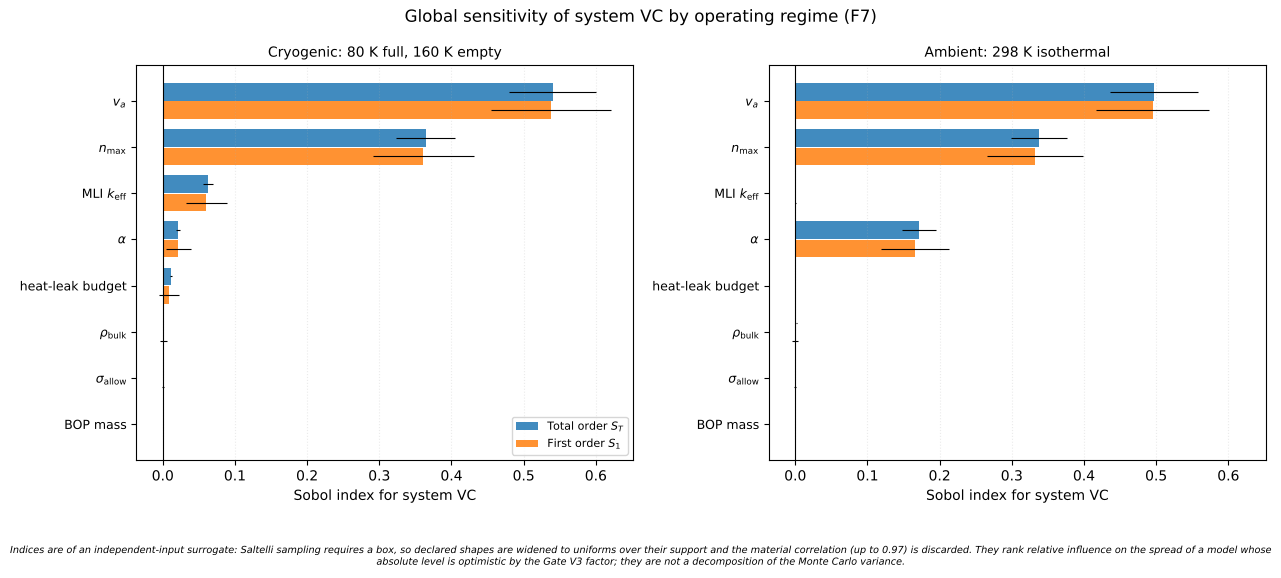

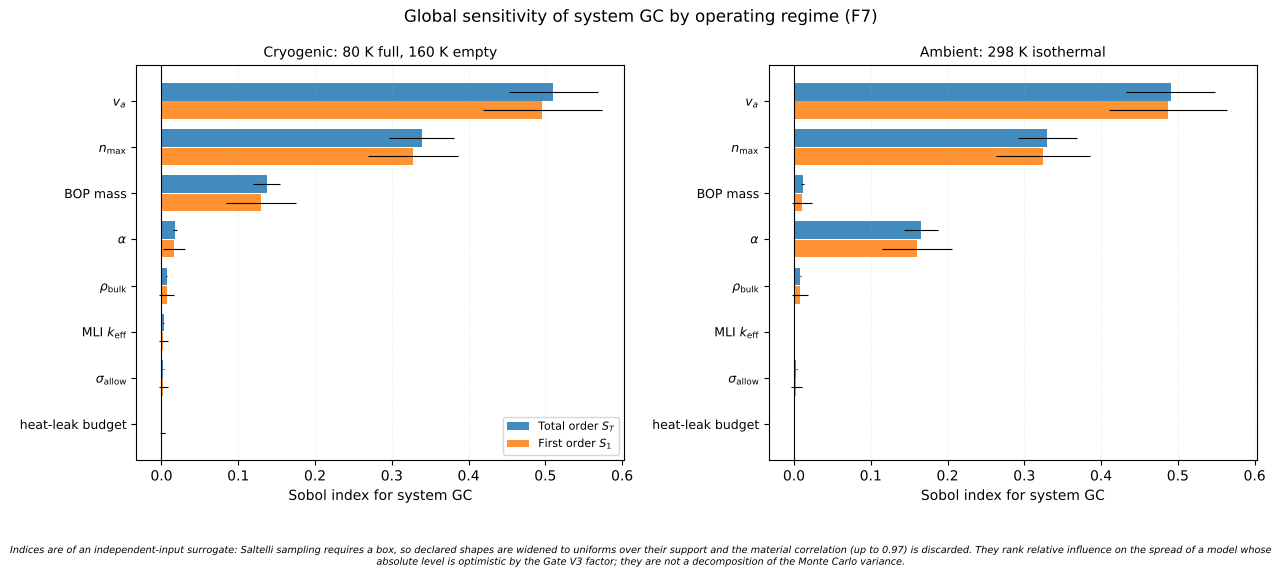

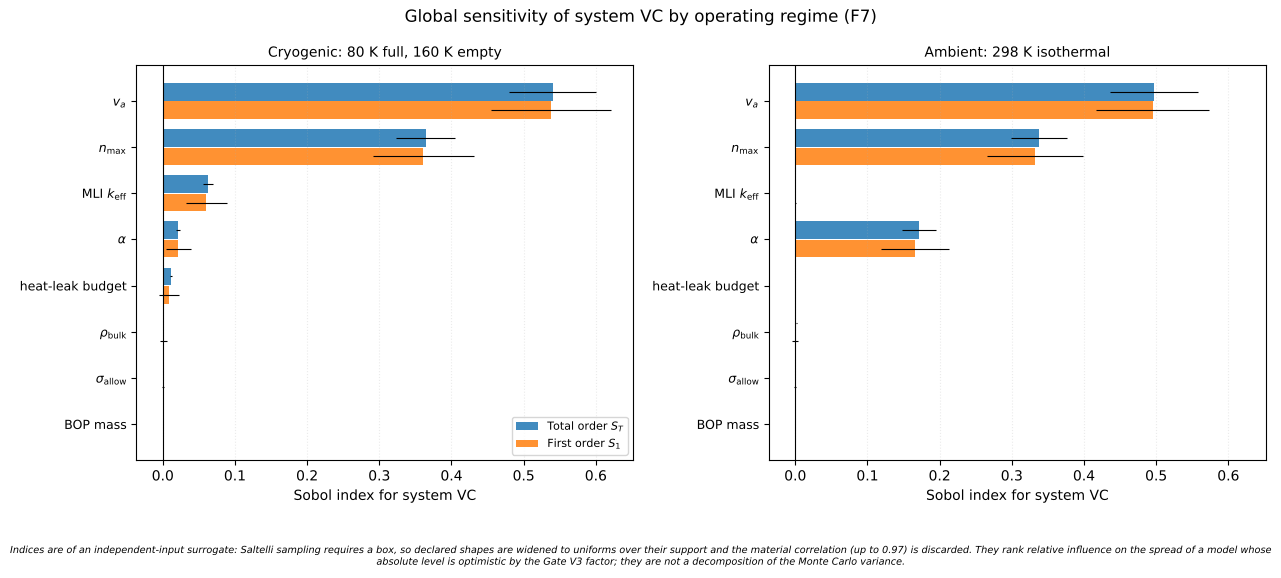

In [9]:
for output in ("GC", "VC"):
    fig, _ = plot_sobol_indices(studies, labels, output=output)
fig

## Figure F6 — the signature result

F6's probability band is the most expensive computation in the project: each
grid node is 1000 system evaluations, each a Brent sizing solve. The grid below
is the published one and takes roughly ten minutes.

The C5 metric is computed on a separate, finer single row at exactly
alpha = 3080 J/mol, because the pre-registration names that line and the
headline number should not be limited by the contour grid's resolution.

In [10]:
alpha_panel = inverse.probability_map(
    spec, material, engineering, "n_max", "alpha",
    np.linspace(70.0, 160.0, 19), np.linspace(2000.0, 5000.0, 7),
    operating_point=baseline, targets=targets,
    n_samples=1000, seed=0, conditional=False)

print(f"P(feasible) spans {np.nanmin(alpha_panel['probability']):.3f} to "
      f"{np.nanmax(alpha_panel['probability']):.3f}")
print(f"nodes with no coherent sample: "
      f"{int((alpha_panel['n_valid'] == 0).sum())}")

P(feasible) spans 0.000 to 1.000
nodes with no coherent sample: 0


In [11]:
c5_row = inverse.probability_map(
    spec, material, engineering, "n_max", "alpha",
    np.linspace(90.0, 170.0, 33), [3080.0],
    operating_point=baseline, targets=targets,
    n_samples=1000, seed=0, conditional=False)

separation = inverse.boundary_separation(c5_row, 3080.0)
for key in ("row_value", "x_at_low", "x_at_median", "x_at_high",
            "separation", "separation_percent", "bounded"):
    print(f"  {key:20s} {separation[key]}")
print()
print(separation["note"])

  row_value            3080.0
  x_at_low             109.41666666666667
  x_at_median          125.5940594059406
  x_at_high            141.51960784313727
  separation           32.102941176470594
  separation_percent   25.5608755129959
  bounded              False

Material-parameter uncertainty alone blurs the feasibility boundary over 32.1 in n_max (25.6% of the median-contour crossing at 126) along alpha = 3080. Conditional on a fixed p0, so a lower bound.


That is claim C5, quantified by a metric fixed before the map was computed.
Material-parameter uncertainty alone blurs the feasibility boundary over about
32 mol/kg in limiting uptake, a quarter of the requirement itself. A point
prediction would quote "126 mol/kg" for a quantity whose own 5-95% range runs
from 109 to 142.

That is the methodological case for curating multi-temperature,
provenance-tiered measurements, which is what HyCAN-DB does. The case is
measured here rather than asserted.

## The pore-volume constraint, and why it is drawn on F6

The deterministic draft of this figure held the adsorbed-phase volume fixed
while sweeping the limiting uptake. That is not a neutral choice: the fit's own
covariance and assumption A-ISO-4's liquid-hydrogen argument both say the
adsorbed phase grows with uptake, and it has to fit inside the pore volume the
packing leaves.

Both limits fall at or below the requirement the map identifies, which means
the requirement is not reachable at AX-21's packing density. A sorbent with
enough uptake would have an adsorbed phase larger than its own pores.

In [12]:
slope_fit = inverse.fit_va_slope(spec.material)
limit_fit = inverse.coherent_n_max_limit(material, slope_fit)
limit_physical = inverse.coherent_n_max_limit(
    material, inverse.V_LIQUID_H2_MOLAR)

print(f"available pore volume      : "
      f"{inverse.pore_volume_available(material):.4e} m^3/kg")
print(f"dv_a/dn_max, fit covariance: {slope_fit:.4e} m^3/mol")
print(f"dv_a/dn_max, A-ISO-4       : "
      f"{inverse.V_LIQUID_H2_MOLAR:.4e} m^3/mol")
print()
print(f"pore volume exhausted at n_max = {limit_fit:.1f} mol/kg (fit)")
print(f"pore volume exhausted at n_max = {limit_physical:.1f} mol/kg (A-ISO-4)")
print(f"requirement (median contour)   = "
      f"{separation['x_at_median']:.1f} mol/kg")

available pore volume      : 2.9001e-03 m^3/kg
dv_a/dn_max, fit covariance: 4.4115e-05 m^3/mol
dv_a/dn_max, A-ISO-4       : 2.8000e-05 m^3/mol

pore volume exhausted at n_max = 104.9 mol/kg (fit)
pore volume exhausted at n_max = 124.1 mol/kg (A-ISO-4)
requirement (median contour)   = 125.6 mol/kg


F6 itself is rendered by `scripts/make_all_figures.py`, which also computes the
second panel in the `(n_max, rho_bulk)` plane where that trade lives: raising
uptake needs more pore volume, which means packing less densely, which costs the
volumetric capacity that is already the binding constraint.

The interpretation of all of this, and the limits on what it may be used to
claim, are written up in `docs/`.